<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Filtragem Adaptativa</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 26 de dezembro de 2025
</div>

<div style="page-break-after: always;"></div>

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.signal import freqz

from optic.dsp.core import firFilter, pulseShape, lowPassFIR, pnorm, decimate, upsample
from optic.plot import eyediagram
from optic.utils import parameters

In [85]:
@njit
def LMS_equalizer(input_signal, desired_signal, mu, num_taps):
    """
    Implements an LMS adaptive equalizer.

    Parameters:
        input_signal: array-like
            The input signal to be equalized.
        desired_signal: array-like
            The desired output signal.
        mu: float
            The step size for the LMS algorithm.
        num_taps: int
            The number of taps (filter coefficients) in the equalizer.
    
    Returns:
        output_signal: array-like
            The equalized output signal.
        error_signal: array-like
            The error signal (difference between desired and output).
        weights: array-like
            The final weights of the equalizer.
    """
    h = np.zeros(num_taps)
    output_signal = np.zeros(len(input_signal))
    MSE = np.zeros(len(input_signal))
    
    for k in range(num_taps, len(input_signal)):
        x_k = input_signal[k-np.arange(num_taps)]
        y = np.dot(h, x_k)
        e = desired_signal[k]-y
        
        h = h + mu*e*x_k
        MSE[k] = e**2
        output_signal[k] = y

    return output_signal, MSE, h

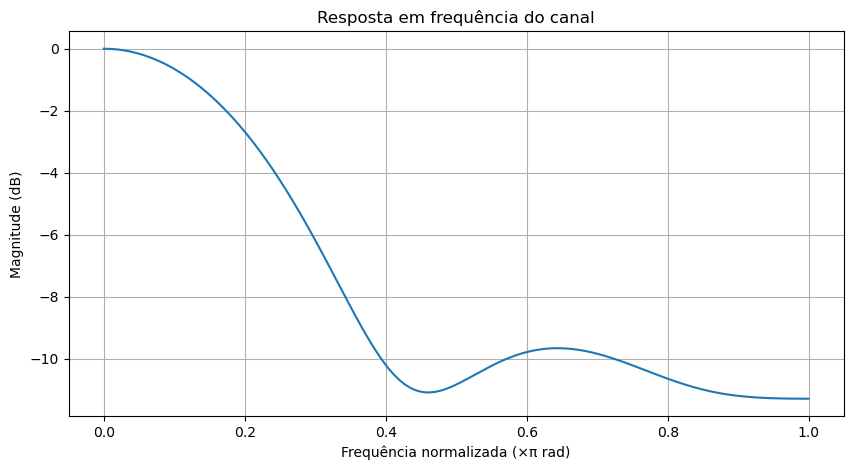

100000 100000 100000


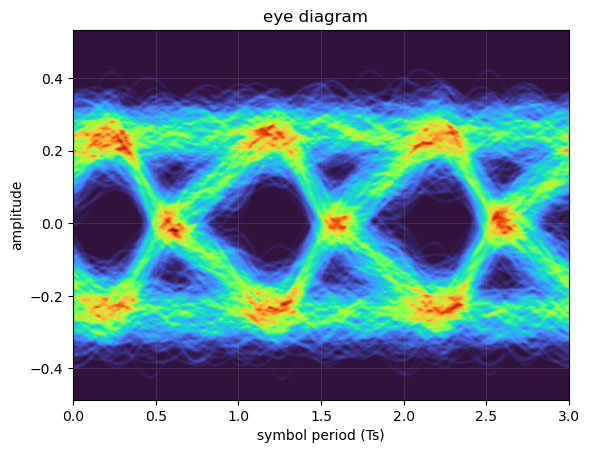

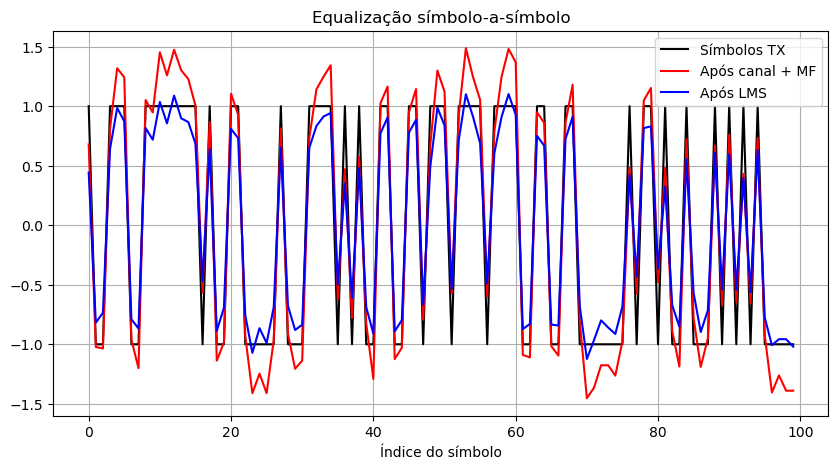

In [ ]:
SpS = 4
mu = 0.001
num_taps = 6

# Decimation parameters
paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1

# Pulse shaping parameters
paramPulse = parameters()
paramPulse.pulseType = 'rect' 
paramPulse.SpS = SpS     

# Generate random BPSK symbols and shape them
symbols = np.random.choice([-1, 1], size=100000)
pulse_shape = pulseShape(paramPulse)

upsampled_symbols = upsample(symbols, SpS)
transmitted_signal = np.convolve(upsampled_symbols, pulse_shape, mode = 'same')

channel = np.array([0.9, 0.5, 0.4, 0.3, 0.1])
channel = channel/np.sum(channel)
w, H = freqz(channel, worN=2048)

plt.figure(figsize=(10,5))
plt.plot(w/np.pi, 20*np.log10(np.abs(H)))
plt.xlabel('Frequência normalizada (×π rad)')
plt.ylabel('Magnitude (dB)')
plt.title('Resposta em frequência do canal')
plt.grid()
plt.show()

# Simulate transmission through the channel with noise
received_signal = np.convolve(transmitted_signal, channel, mode = 'same')
received_signal = np.roll(received_signal, 1)

noise = np.random.normal(0, 0.05, len(received_signal))
received_signal += noise
rx = np.convolve(received_signal, pulse_shape[::-1], 'same')

# Downsample the received signal to symbol rate
rx_sym = decimate(rx, paramDec)
rx_sym = pnorm(rx_sym)

out, mse, h = LMS_equalizer(rx_sym, symbols, mu, num_taps)
eyediagram(received_signal, len(received_signal), SpS, ptype = 'fancy')


N = 1500
plt.figure(figsize=(10,5))
plt.plot(symbols[N:N+100], '-k', label='Símbolos TX')
plt.plot(rx_sym[N:N+100], '-r', label='Após canal + MF')
plt.plot(out[N:N+100], '-b', label='Após LMS')
plt.legend()
plt.grid()
plt.title('Equalização símbolo-a-símbolo')
plt.xlabel('Índice do símbolo')
plt.show()

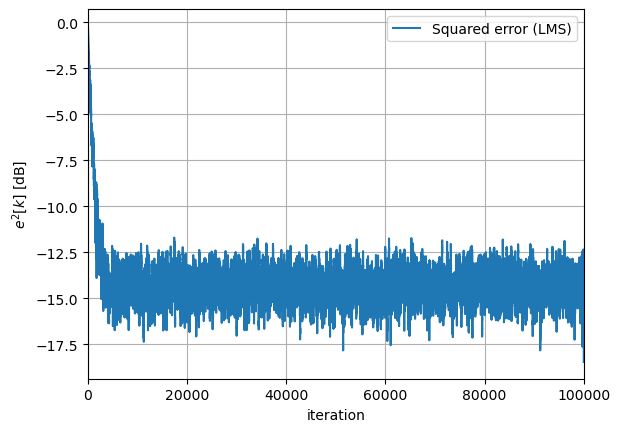

In [87]:
average_window_len = 50
error_dB = 10*np.log10(np.convolve(mse,np.ones(average_window_len)/average_window_len, 'same'))

plt.plot(error_dB, label='Squared error (LMS)')
plt.xlim(0,len(error_dB))
plt.xlabel('iteration')
plt.ylabel('$e^2[k]$ [dB]')
plt.legend()
plt.grid()